In [5]:
path = '../data/raw/war_and_peace_en.txt'

with open(path, 'r', encoding='utf-8') as f:
    text = f.read()

print('Total characters:', len(text))

Total characters: 3202303


In [6]:
unique_chars = sorted(list(set(text)))
print('Vocab size:', len(unique_chars))
print('All characters:', unique_chars)

Vocab size: 82
All characters: ['\n', ' ', '!', '"', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'à', 'ä', 'é', 'ê']


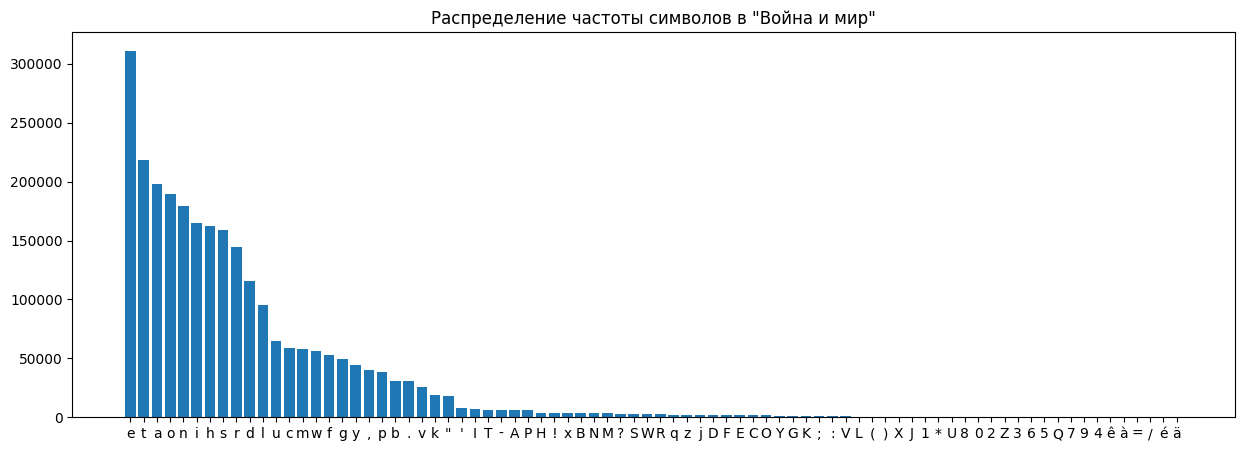

In [7]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

char_counts = Counter(text)
char_counts.pop(' ')
char_counts.pop('\n')

sorted_chars = char_counts.most_common()
chars = [char for char, count in sorted_chars]
counts = [count for char, count in sorted_chars]

plt.figure(figsize=(15, 5))
plt.bar(chars, counts)
plt.title('Распределение частоты символов в "Война и мир"')
plt.show()

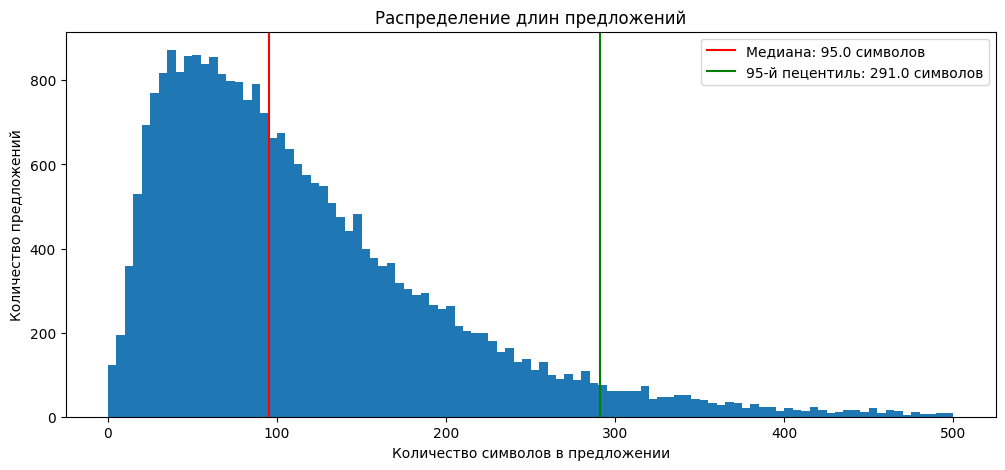

In [21]:
sentences = text.split('.')

sentences_len = [len(sentence.strip()) for sentence in sentences if len(sentence.strip()) > 0]

percentile_95 = np.percentile(sentences_len, 95)
median = np.median(sentences_len)

plt.figure(figsize=(12, 5))
plt.hist(sentences_len, bins=100, range=(0, 500))
plt.axvline(median, color='red', label=f'Медиана: {median} символов')
plt.axvline(percentile_95, color='green', label=f'95-й пецентиль: {percentile_95} символов')
plt.title('Распределение длин предложений')
plt.xlabel('Количество символов в предложении')
plt.ylabel('Количество предложений')
plt.legend()
plt.show()

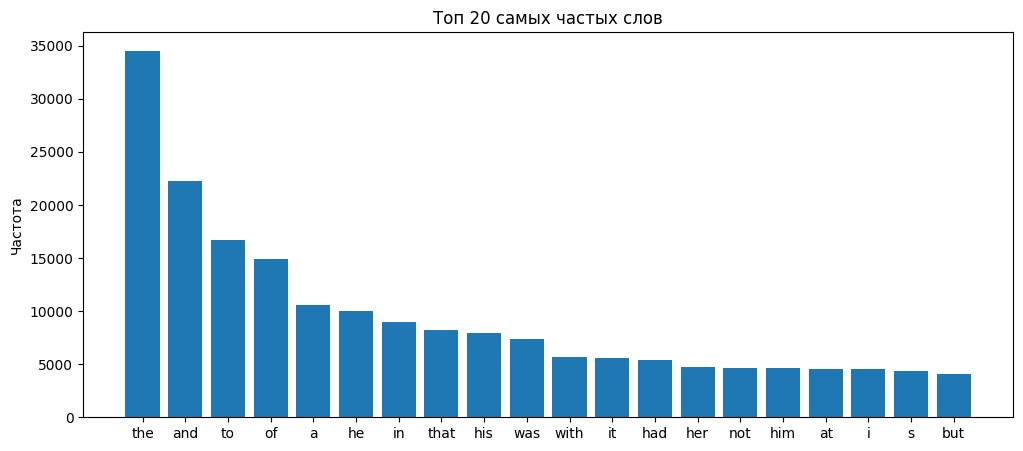

In [25]:
import re

all_words = re.sub(r'[^a-z \n]', ' ', text.lower()).split()
word_counts = Counter(all_words)

top_words = word_counts.most_common(20)
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.title('Топ 20 самых частых слов')
plt.ylabel('Частота')
plt.show()